# Week 8 Homework: Hierarchical Clustering — ANSWER KEY

## Purpose of Homework

This homework will give you practice applying **hierarchical clustering** to explore structure in a real-world dataset of recipes from around the world. Unlike supervised methods, clustering is **unsupervised**: the goal is to discover natural groupings in the data.

You will build and interpret a **dendrogram**, choose the number of clusters, profile each cluster using summary statistics and visualizations, and reflect on what the clusters reveal about global cuisine.

## Logistics

Due date: The homework is due **11:59pm on Thursday, March 26, 2026**.

You will submit your homework on [MarkUs](https://markus.teach.cs.toronto.edu/markus/).

1. Download this file (`STA272_hw8_student.ipynb`) from JupyterHub. (See [our JupyterHub Guide](../guides/jupyterhub_guide.ipynb) for detailed instructions.)
2. Submit this file to MarkUs under the hw8 assignment. (See [our MarkUs Guide](../guides/markus_guide.ipynb) for detailed instructions.)

All homeworks will take place in a Jupyter notebook (like this one). When you are done, you will download this notebook and submit it to MarkUs.

## About the Data

The **cuisines_clean** dataset contains 1,688 recipes drawn from over 20 distinct world cuisines. Each recipe includes nutritional information, preparation and cooking times, user ratings, and country of origin.

**Research Question:** Can we identify natural groups of recipes based on their nutritional profiles and preparation characteristics? Do these groups correspond to recognisable culinary traditions or dish types?

### Variables

| Variable | Description | Type |
|----------|-------------|------|
| `name` | Recipe name | Text |
| `country` | Cuisine origin | Categorical |
| `calories` | Total calories per serving | Numeric |
| `fat` | Fat content (grams) | Numeric |
| `carbs` | Carbohydrate content (grams) | Numeric |
| `protein` | Protein content (grams) | Numeric |
| `avg_rating` | Average user rating (0–5) | Numeric |
| `prep_time` | Preparation time (minutes) | Numeric |
| `cook_time` | Cooking time (minutes) | Numeric |
| `total_time` | Total time (minutes) | Numeric |
| `servings` | Number of servings | Numeric |
| `pct_fat` | Percentage of calories from fat | Numeric |
| `pct_carbs` | Percentage of calories from carbs | Numeric |
| `pct_protein` | Percentage of calories from protein | Numeric |

## Task #1: Load and Explore the Data

Load `cuisines_clean.csv` into a DataFrame called `cuisines_df`.

1. Print the **shape** of the DataFrame.
2. Display the **first 5 rows**.
3. Print the **top 10 countries** by number of recipes using `value_counts()`.
4. Print **summary statistics** for the numeric columns using `.describe()`.

In [19]:
# Task #1 — Answer

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load the data
cuisines_df = pd.read_csv('cuisines_clean.csv')

# 1. Print shape
print(f'Shape: {cuisines_df.shape}')
# Expected: (1688, 14)

# 2. Display first 5 rows
display(cuisines_df.head(5))

# 3. Top 10 countries by recipe count
print('\nTop 10 countries by recipe count:')
print(cuisines_df['country'].value_counts().head(10))
# Canadian (60), Chinese (59), Russian (58), Filipino (56), Indian (56), ...

# 4. Summary statistics
print('\nSummary statistics:')
display(cuisines_df.describe())

Shape: (1688, 14)


,name,country,calories,fat,carbs,protein,avg_rating,prep_time,cook_time,total_time,servings,pct_fat,pct_carbs,pct_protein
0,Saganaki (Flaming Greek Cheese),Greek,391.0,25.0,15.0,16.0,4.8,10,5,15,2.0,0.575448,0.153453,0.163683
1,Coney Island Knishes,Jewish,301.0,17.0,31.0,7.0,4.6,30,75,180,16.0,0.508306,0.411960,0.093023
2,Diana's Hawaiian Bread Rolls,Australian and New Zealander,64.0,3.0,9.0,1.0,4.3,20,15,180,12.0,0.421875,0.562500,0.062500
3,Chilean Pebre,Chilean,106.0,9.0,7.0,1.0,5.0,10,0,10,6.0,0.764151,0.264151,0.037736
4,Tex-Mex Sheet Cake,Tex-Mex,449.0,23.0,58.0,7.0,3.8,30,15,45,15.0,0.461024,0.516704,0.062361



Top 10 countries by recipe count:
country
Canadian                        60
Chinese                         59
Russian                         58
Filipino                        56
Indian                          56
Australian and New Zealander    54
French                          54
Thai                            51
Brazilian                       50
Jewish                          50
Name: count, dtype: int64

Summary statistics:


,calories,fat,carbs,protein,avg_rating,prep_time,cook_time,total_time,servings,pct_fat,pct_carbs,pct_protein
count,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000
mean,345.544431,17.566943,32.075829,15.648104,4.497630,18.571682,34.572867,73.189573,8.963863,0.442855,0.400154,0.170748
std,181.913120,12.332828,21.992566,13.497129,0.408425,11.085306,34.835740,57.746371,7.333806,0.183134,0.214669,0.116436
min,50.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.008299,0.000000
25%,205.750000,8.000000,15.000000,4.000000,4.300000,10.000000,15.000000,34.750000,4.000000,0.318965,0.226169,0.076923
50%,316.500000,15.000000,28.000000,11.000000,4.600000,15.000000,25.000000,60.000000,6.000000,0.444837,0.403713,0.145455
75%,464.250000,25.000000,45.000000,25.000000,4.800000,25.000000,45.000000,90.000000,10.000000,0.569007,0.554580,0.242424
max,1018.000000,62.000000,109.000000,64.000000,5.000000,60.000000,210.000000,300.000000,48.000000,0.995745,1.085106,0.716049


## Task #2: Select Features and Standardize

Hierarchical clustering is sensitive to the scale of variables — features measured in large units (e.g., calories in the hundreds) will dominate features measured in small units (e.g., average rating on a 0–5 scale) unless we standardize first.

1. Define `feature_cols` as the list below and create `X_cluster = cuisines_df[feature_cols].copy()`.

   ```python
   feature_cols = ['calories', 'fat', 'carbs', 'protein', 'avg_rating', 'prep_time', 'cook_time', 'servings']
   ```

2. Drop any rows with missing values using `.dropna()`. Store the cleaned subset as `X_cluster` and print its shape.

3. Standardize using `StandardScaler`: fit **only** on `X_cluster` and transform to produce `X_scaled` (a NumPy array).

4. Print the **mean** and **standard deviation** of each scaled column (they should be approximately 0 and 1).

In [20]:
# Task #2 — Answer

from sklearn.preprocessing import StandardScaler

# 1. Select features
feature_cols = ['calories', 'fat', 'carbs', 'protein', 'avg_rating', 'prep_time', 'cook_time', 'servings']
X_cluster = cuisines_df[feature_cols].copy()

# 2. Drop missing values
X_cluster = X_cluster.dropna()
print(f'Shape after dropping missing values: {X_cluster.shape}')

# 3. Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# 4. Check means and standard deviations
print(f'\nMean of scaled features (should be ~0):')
print(pd.Series(X_scaled.mean(axis=0).round(4), index=feature_cols))
print(f'\nStd of scaled features (should be ~1):')
print(pd.Series(X_scaled.std(axis=0).round(4), index=feature_cols))

Shape after dropping missing values: (1688, 8)

Mean of scaled features (should be ~0):
calories     -0.0
fat           0.0
carbs        -0.0
protein       0.0
avg_rating    0.0
prep_time    -0.0
cook_time     0.0
servings      0.0
dtype: float64

Std of scaled features (should be ~1):
calories      1.0
fat           1.0
carbs         1.0
protein       1.0
avg_rating    1.0
prep_time     1.0
cook_time     1.0
servings      1.0
dtype: float64


## Task #3: Compute the Linkage Matrix and Plot the Dendrogram

A **dendrogram** is a tree diagram that shows how individual observations are merged step by step into larger and larger clusters. The height at which two branches merge reflects the **distance** between them — taller merges mean more dissimilar groups.

1. Import `linkage` and `dendrogram` from `scipy.cluster.hierarchy`.
2. Compute the linkage matrix `Z` using **Ward's method** (`method='ward'`) on `X_scaled`.
3. Plot the dendrogram, **truncated to the last 30 merges** (use `truncate_mode='lastp'`, `p=30`). Add axis labels and a title.
4. Add a **horizontal dashed line** at the cut height you think best separates the clusters, using `plt.axhline()`.
5. Compute **silhouette scores** for k = 2 to 10 using `silhouette_score` from `sklearn.metrics` and `fcluster` from `scipy.cluster.hierarchy`. Print the scores, identify the best k, and plot the scores as a line chart.

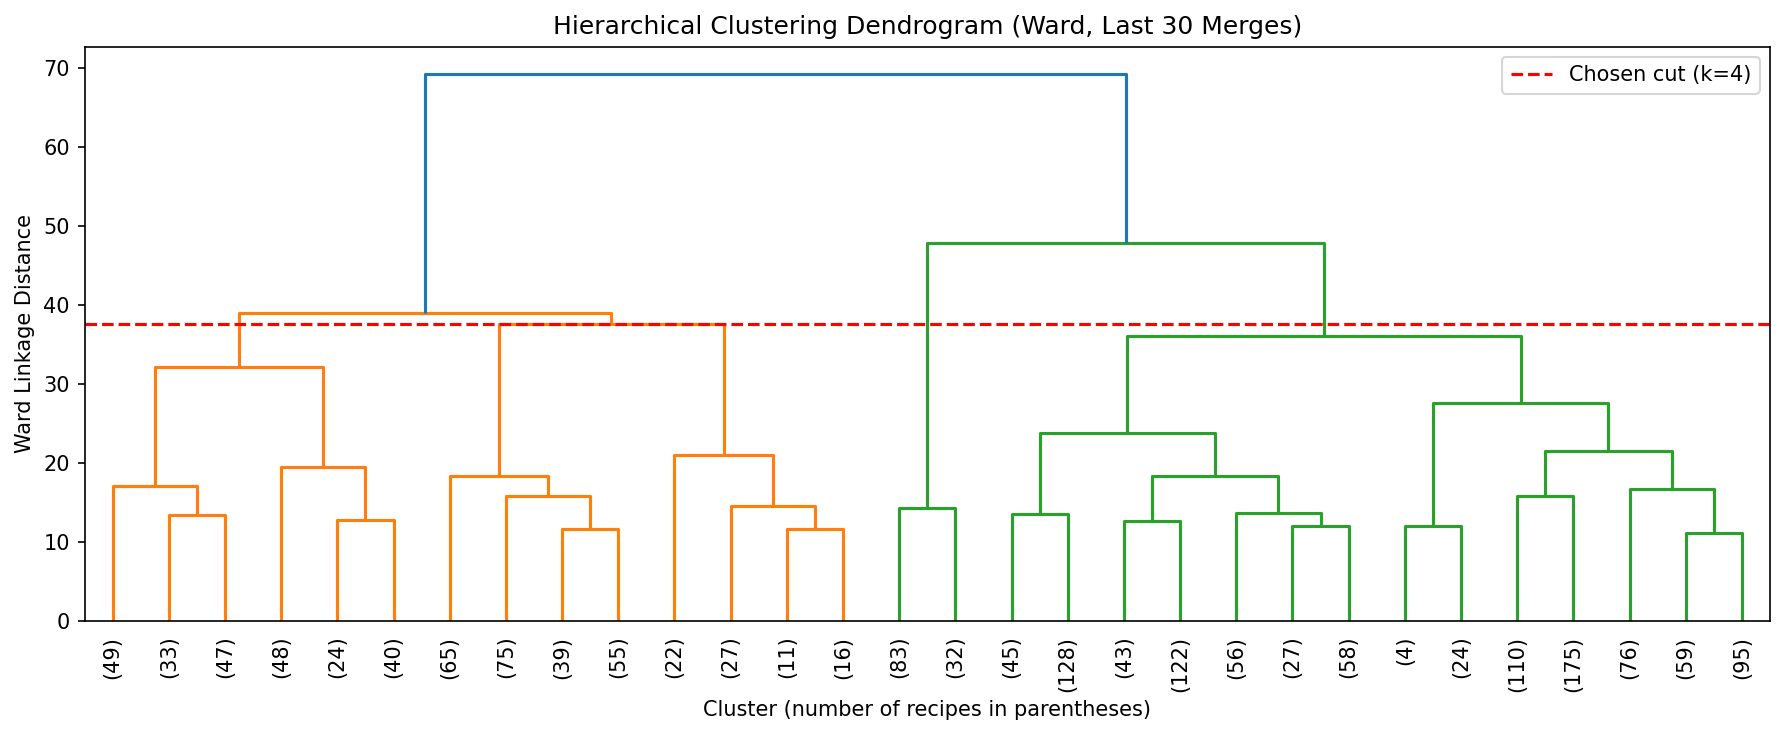

Silhouette scores by k:
  k=2: 0.2229  <-- best
  k=3: 0.1969
  k=4: 0.1984
  k=5: 0.1918
  k=6: 0.1126
  k=7: 0.1240
  k=8: 0.1282
  k=9: 0.1149
  k=10: 0.0967


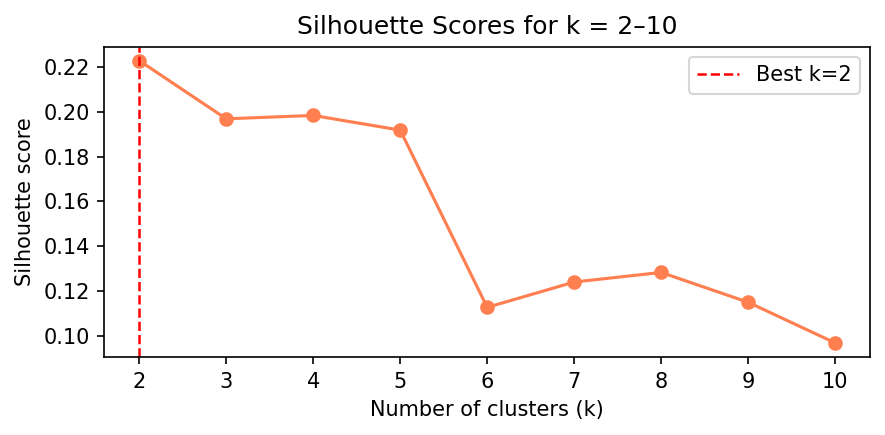

In [21]:
# Task #3 — Answer

from scipy.cluster.hierarchy import linkage, dendrogram

# Compute Ward linkage matrix
Z = linkage(X_scaled, method='ward')

k = 4

# Plot the truncated dendrogram
plt.figure(figsize=(12, 5), dpi=150)
dendrogram(
    Z,
    truncate_mode='lastp',
    p=30,
    show_leaf_counts=True,
    leaf_rotation=90,
    color_threshold=0.7 * max(Z[:, 2])
)
plt.xlabel('Cluster (number of recipes in parentheses)')
plt.ylabel('Ward Linkage Distance')
plt.title('Hierarchical Clustering Dendrogram (Ward, Last 30 Merges)')

plt.axhline(y=Z[-k, 2], color='red', linestyle='--', linewidth=1.5,
            label=f'Chosen cut (k={k})')
plt.legend()
plt.tight_layout()
plt.show()

# Silhouette scores for k = 2–10
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import fcluster

k_range = range(2, 11)
sil_scores = {}
for k in k_range:
    labels = fcluster(Z, t=k, criterion='maxclust')
    sil_scores[k] = silhouette_score(X_scaled, labels)

best_k = max(sil_scores, key=sil_scores.get)
print('Silhouette scores by k:')
for k, s in sil_scores.items():
    marker = '  <-- best' if k == best_k else ''
    print(f'  k={k}: {s:.4f}{marker}')

plt.figure(figsize=(6, 3), dpi=150)
plt.plot(list(sil_scores.keys()), list(sil_scores.values()), marker='o', color='coral')
plt.axvline(x=best_k, color='red', linestyle='--', linewidth=1.2, label=f'Best k={best_k}')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette score')
plt.title('Silhouette Scores for k = 2–10')
plt.xticks(list(k_range))
plt.legend()
plt.tight_layout()
plt.show()

## Task #4: Cut the Dendrogram and Assign Cluster Labels

Use `fcluster` to cut the dendrogram using the best k identified by the silhouette score in Task #3.

1. Import `fcluster` from `scipy.cluster.hierarchy`.
2. Use `best_k` from Task #3 as the number of clusters. Call `fcluster(Z, t=best_k, criterion='maxclust')` to obtain cluster labels (1-indexed). Store as `cluster_labels`.
3. Create `cuisines_clustered` by taking the rows of `cuisines_df` that correspond to `X_cluster` (use `.loc[X_cluster.index]`) and adding a `'cluster'` column.
4. Print the **size** of each cluster using `value_counts()`, sorted by cluster number.

In [22]:
# Task #4 — Answer

from scipy.cluster.hierarchy import fcluster

# Cut dendrogram using best_k from silhouette scores
cluster_labels = fcluster(Z, t=best_k, criterion='maxclust')

# Add cluster labels to a copy of the relevant rows
cuisines_clustered = cuisines_df.loc[X_cluster.index].copy()
cuisines_clustered['cluster'] = cluster_labels

# Print cluster sizes
print('Cluster sizes:')
print(cuisines_clustered['cluster'].value_counts().sort_index())

Cluster sizes:
cluster
1     551
2    1137
Name: count, dtype: int64


## Task #5: Profile the Clusters

To interpret the clusters we identified, we compute the **mean value of each feature** within each cluster and visualise the result as a heatmap.

1. Compute the mean of each column in `feature_cols` grouped by `'cluster'`. Store as `cluster_means` and display it.
2. Rescale `cluster_means` back to standardized units using `scaler.transform()`. Store as a DataFrame called `cluster_means_scaled` with the same index and column names.
3. Create a **heatmap** of `cluster_means_scaled` using `sns.heatmap()` with `annot=True`, `cmap='RdBu_r'`, and `center=0`. Label rows as `'Cluster 1'`, `'Cluster 2'`, etc.

Mean feature values by cluster:


,calories,fat,carbs,protein,avg_rating,prep_time,cook_time,servings
cluster,,,,,,,,
1,520.11,27.38,43.18,25.95,4.5,23.25,54.20,7.39
2,260.95,12.81,26.70,10.66,4.5,16.31,25.06,9.73


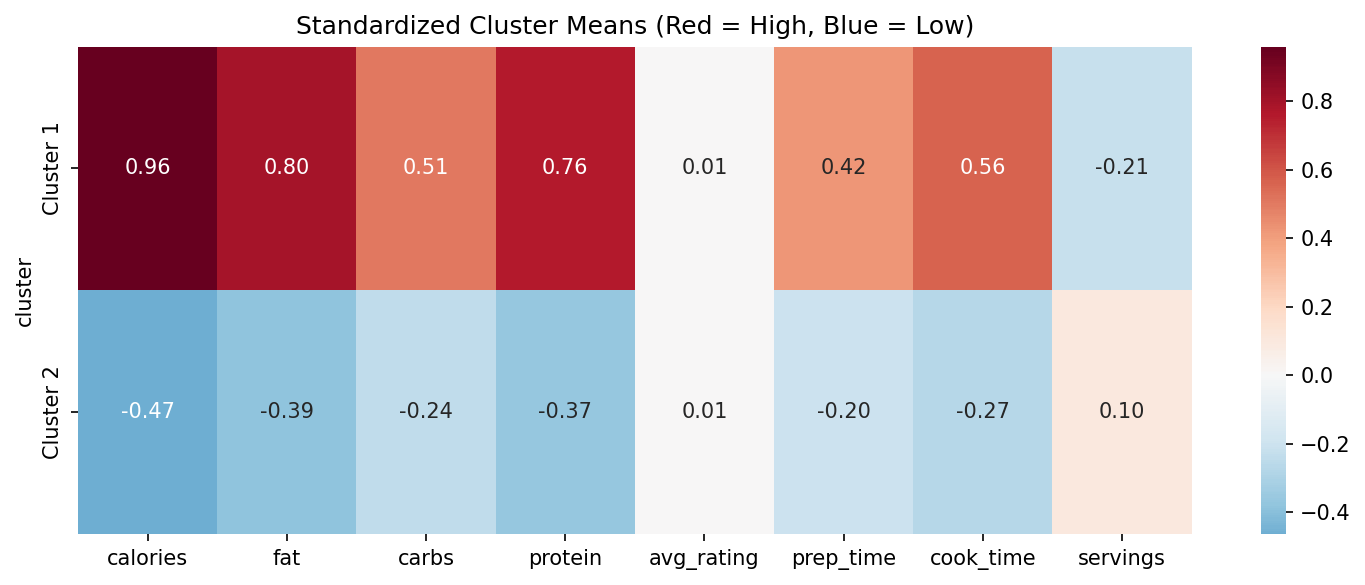

In [23]:
# Task #5 — Answer

import seaborn as sns

# 1. Compute mean features by cluster
cluster_means = cuisines_clustered.groupby('cluster')[feature_cols].mean().round(2)
print('Mean feature values by cluster:')
display(cluster_means)

# 2. Rescale cluster means to standardized units for the heatmap
cluster_means_scaled = pd.DataFrame(
    scaler.transform(cluster_means),
    index=cluster_means.index,
    columns=feature_cols
)

# 3. Heatmap
plt.figure(figsize=(10, 4), dpi=150)
sns.heatmap(
    cluster_means_scaled,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    xticklabels=feature_cols,
    yticklabels=[f'Cluster {i}' for i in cluster_means.index]
)
plt.title('Standardized Cluster Means (Red = High, Blue = Low)')
plt.tight_layout()
plt.show()

## Task #6: Visualize Clusters with Scatter Plots

Create **two side-by-side scatter plots** to visualise the clusters in feature space.

- **Left plot:** `calories` (x-axis) vs `protein` (y-axis), with points coloured by cluster.
- **Right plot:** `fat` (x-axis) vs `carbs` (y-axis), with points coloured by cluster.

Use `alpha=0.5` and `s=20` for the scatter points. Add axis labels, titles, and a legend to each plot.

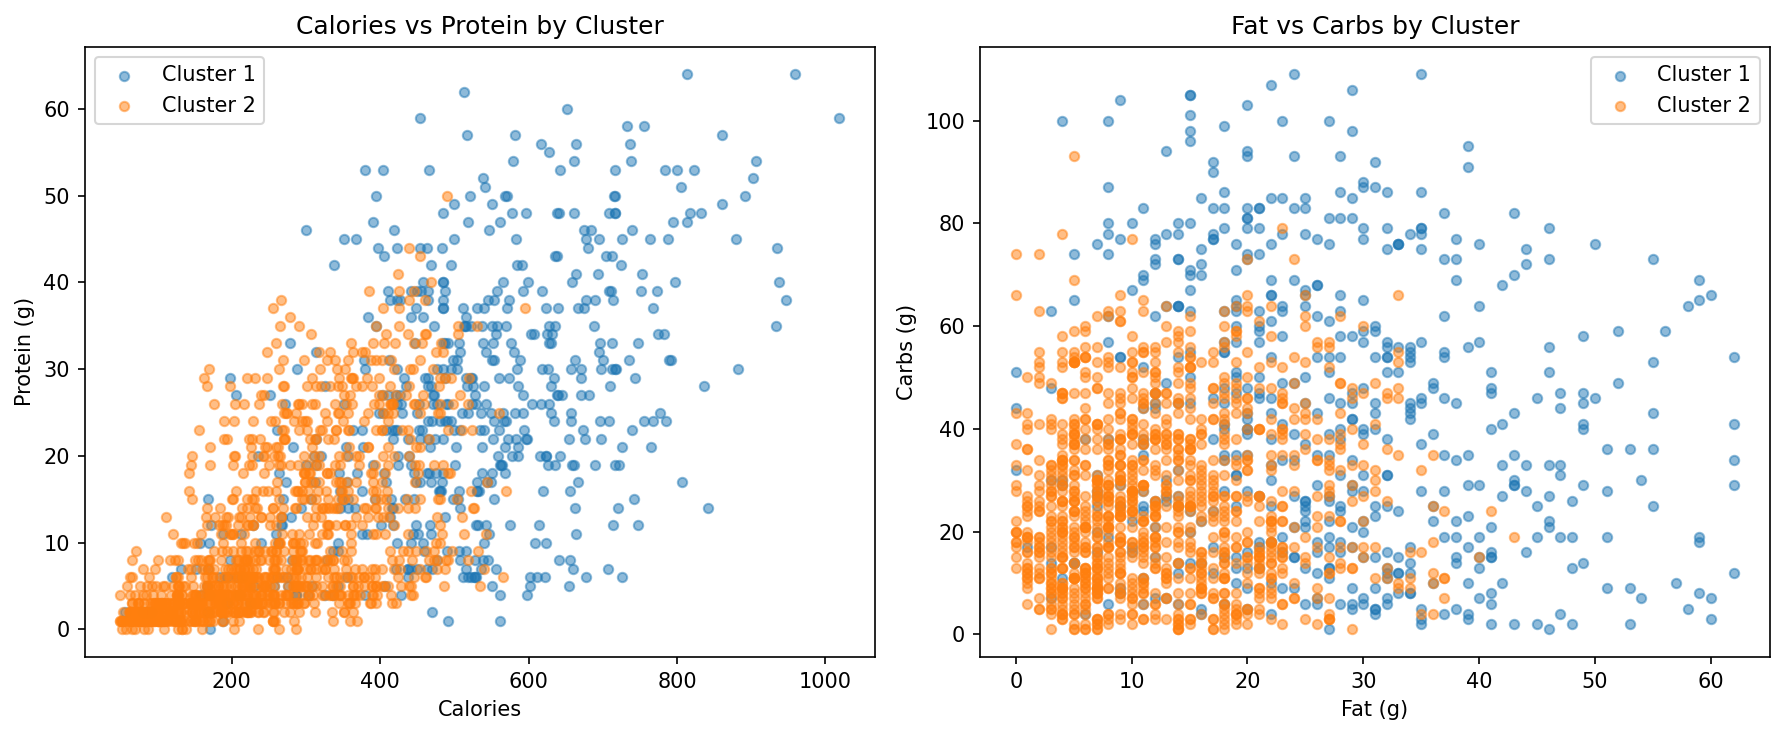

In [24]:
# Task #6 — Answer

cmap = plt.get_cmap('tab10')
colors = {k: cmap(i) for i, k in enumerate(sorted(cuisines_clustered['cluster'].unique()))}

fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=150)

for c in sorted(cuisines_clustered['cluster'].unique()):
    mask = cuisines_clustered['cluster'] == c

    # Left plot: calories vs protein
    axes[0].scatter(
        cuisines_clustered.loc[mask, 'calories'],
        cuisines_clustered.loc[mask, 'protein'],
        alpha=0.5, s=20, label=f'Cluster {c}', color=colors[c]
    )

    # Right plot: fat vs carbs
    axes[1].scatter(
        cuisines_clustered.loc[mask, 'fat'],
        cuisines_clustered.loc[mask, 'carbs'],
        alpha=0.5, s=20, label=f'Cluster {c}', color=colors[c]
    )

axes[0].set_xlabel('Calories')
axes[0].set_ylabel('Protein (g)')
axes[0].set_title('Calories vs Protein by Cluster')
axes[0].legend()

axes[1].set_xlabel('Fat (g)')
axes[1].set_ylabel('Carbs (g)')
axes[1].set_title('Fat vs Carbs by Cluster')
axes[1].legend()

plt.tight_layout()
plt.show()

## Task #7: Cuisine Breakdown by Cluster

Explore which cuisines are most represented in each cluster.

1. Use `groupby` on `['cluster', 'country']` and `.size()` to count recipes per country within each cluster. Reset the index and name the count column `'count'`.
2. Sort so that within each cluster, countries are ordered from most to fewest recipes.
3. Use `.groupby('cluster').head(5)` to keep the **top 5 countries per cluster** and reset the index. Store as `top_countries`.
4. Display `top_countries`.

In [25]:
# Task #7 — Answer

# Count recipes per country within each cluster
country_by_cluster = (
    cuisines_clustered
    .groupby(['cluster', 'country'])
    .size()
    .reset_index(name='count')
    .sort_values(['cluster', 'count'], ascending=[True, False])
)

# Top 5 countries per cluster
top_countries = (
    country_by_cluster
    .groupby('cluster')
    .head(5)
    .reset_index(drop=True)
)

display(top_countries)

,cluster,country,count
0,1,Cajun and Creole,26
1,1,Italian,25
2,1,Vietnamese,25
3,1,Chinese,21
4,1,Canadian,20
5,2,Australian and New Zealander,44
6,2,Russian,42
7,2,Jewish,41
8,2,Canadian,40
9,2,Indian,40


---

## Question #1: Dendrogram Interpretation and Cluster Choice (5 marks)

Answer the following based on your dendrogram and silhouette plot from Task #3 and your cluster assignments from Task #4. Your answer should address **all five** of the following for full marks.

1. **Describe the dendrogram.** Where does the largest "jump" in linkage distance appear? What does this suggest about the natural number of clusters in the data? (1 mark)

2. **Explain Ward's method.** What quantity does Ward's linkage minimise at each merge step? How might the dendrogram look different if we had used **single linkage** instead? (1 mark)

3. **Justify standardization.** Why is it important to standardize the features before clustering? What could go wrong if we clustered on the raw (unstandardized) features from this dataset? Give a concrete example using two of the features. (1 mark)

4. **Sensitivity to cut height.** If you cut the dendrogram at a Ward Linkage Distance of just under 40, how many clusters would you obtain? How would this have affected the cluster profiles and your interpretation compared to the cut you chose? (1 mark)

5. **Silhouette score vs. dendrogram.** Does the k with the highest silhouette score agree with the k you chose from the dendrogram? If they differ, which would you trust more for this dataset and why? (1 mark)

---

**Question #1 — Suggested Answer**

1. **Dendrogram.** The largest jump in linkage distance (the tallest vertical line before the final few merges) in the truncated dendrogram typically appears between 2 and 4 clusters. A large gap just above the merge height for 4 branches suggests that 4 is a natural number of clusters — splitting below this threshold creates relatively tight groups, while merging above it forces together dissimilar groups. Students may report slightly different values depending on where they placed the horizontal line, but k = 3 to 5 are all defensible given the data.

2. **Ward's method.** Ward's linkage minimises the **total within-cluster sum of squared distances** (i.e., within-cluster variance) at each merge step. This tends to produce compact, similarly-sized clusters and clear dendrogram structure. Single linkage, by contrast, defines cluster distance as the distance between the *closest* pair of points across two groups. This can produce long, chain-like clusters (the "chaining" effect) and a dendrogram where the merge heights increase very gradually, making it harder to identify a natural cut point.

3. **Standardization.** Without standardization, features with large numeric ranges dominate the distance calculations. For example, `total_time` has values in the hundreds of minutes (some recipes take over 500 minutes), while `avg_rating` only ranges from roughly 3 to 5. In Euclidean distance, a difference of 200 minutes in cook time would completely swamp a difference of 0.5 in rating, so the clustering would be driven almost entirely by time rather than by the combination of nutritional and quality features we care about. Standardizing ensures each feature contributes equally.

4. **Sensitivity to cut height.** Cutting at a Ward Linkage Distance of just under 40 yields approximately 4 clusters. Since the silhouette score selects k = 2 as the best cut, this represents a finer partition than the chosen solution — splitting the two broad groups into four more specific ones. The 4-cluster solution reveals more granular structure (e.g., distinguishing high-fat from high-protein dishes within what was a single "hearty" group), but the clusters are less well-separated by the silhouette metric. Whether this additional detail is useful depends on the research question.

5. **Silhouette vs. dendrogram.** The silhouette score measures the average tightness and separation of clusters — a value closer to 1 indicates well-separated, compact clusters. For this dataset, k = 2 produces the highest silhouette score, with k = 4 coming in second. This means that, purely by the silhouette metric, the data is most cleanly divided into two broad groups. However, k = 2 is a very coarse partition that likely collapses meaningful culinary distinctions — for example, lumping together all high-protein meat dishes regardless of cuisine. The dendrogram supports k = 4 as a more informative cut, where the clusters have distinct and interpretable nutritional profiles. When the two methods disagree, neither is definitively correct: silhouette captures *how well* each point fits its cluster, but can favour broad, well-separated groups at the expense of interpretability. A strong answer acknowledges that k = 2 scores highest but argues that k = 4 is more useful given the research question.

---

---

## Question #2: Cluster Interpretation (4 marks)

Answer the following based on your cluster profile heatmap from Task #5, the scatter plots from Task #6, and the country breakdown from Task #7. Your answer should address **all four** of the following for full marks.

1. **Name each cluster.** Give each of the four clusters a brief, descriptive name (e.g., "Quick, low-calorie sides") based on its nutritional and timing profile from the heatmap. Explain your reasoning for at least two of the names. (1 mark)

2. **Connect clusters to dishes.** Choose one cluster and name two specific dishes from a real cuisine that you would expect to fall into it. Explain why, using the cluster's feature values. (1 mark)

3. **Evaluate the cuisine breakdown.** Does the cuisine breakdown in Task #7 match what you would expect given each cluster's profile? Give one specific example where the match is **surprising or noteworthy** and explain why. (1 mark)

4. **Identify a limitation.** Identify one limitation of using hierarchical clustering for this recipe dataset and explain how it might affect the conclusions you can draw. (1 mark)

---

**Question #2 — Suggested Answer**

1. **Cluster names:**
   - *Cluster 1: High-calorie, protein-rich dishes* — well above average in calories and protein, with the scatter plot showing a clear upward separation from Cluster 2 on both axes. Fat is also elevated but is less distinctive than calories and protein. Likely meat-based mains and hearty entrees served in modest portions.
   - *Cluster 2: Large-batch, lower-calorie dishes* — lower calories and protein per serving, but notably higher servings. The fat vs. carbs scatter plot shows much less separation between the two clusters than the calories vs. protein plot, confirming that calories and protein are the primary drivers of the split. Average rating is similar across both clusters and does not help distinguish them.
   Students receive credit for names that are clearly grounded in the heatmap and scatter plot, with reasoning for both clusters.

2. **Dishes in a cluster.** Cluster 1's high-calorie, high-protein profile is well illustrated by dishes like Korean *bulgogi* (marinated grilled beef) and Italian *osso buco* (braised veal shank) — both are protein-dense, individually portioned mains. These sit clearly in the upper-right of the calories vs. protein scatter plot, where the two clusters diverge most visibly. Cluster 2 dishes such as Indian *dal* or Russian *borscht* tend to be lower in protein per serving but are made in large quantities, consistent with that cluster's high-servings profile.

3. **Country breakdown.** The top cuisines in Cluster 1 are Cajun and Creole, Italian, Vietnamese, Chinese, and Canadian. The top cuisines in Cluster 2 are Australian and New Zealander, Russian, Jewish, Canadian, and Indian. Russian and Jewish cuisines dominating Cluster 2 is expected — both traditions feature large-batch dishes like borscht, kugel, and casseroles. A surprising finding is Vietnamese appearing in Cluster 1 (high calories and protein), given that Vietnamese cuisine is often associated with lighter broths and fresh herbs — this may reflect that the recipes in the dataset skew toward richer Vietnamese dishes. Canadian appearing in both top-5 lists suggests its recipes span both clusters.

4. **Limitation.** Hierarchical clustering is **deterministic but scale-dependent**: the result is strongly influenced by which features we include and how we scale them. We clustered on only 8 of the 14 available features, so the clusters reflect nutritional and time dimensions but ignore the macronutrient percentage breakdown (`pct_fat`, `pct_carbs`, `pct_protein`), which might reveal different groupings. Another valid limitation: with only k = 2 clusters, the solution is coarse — many recipes that differ meaningfully in preparation style or cuisine tradition are grouped together, limiting the interpretability of the clusters as distinct culinary types.

---